In [1]:
# Required imports
import gempy as gp
import gempy_viewer as gpv


Setting Backend To: AvailableBackends.numpy


In [2]:
# Path to input data
data_path = "https://raw.githubusercontent.com/cgre-aachen/gempy_data/master/"
path_to_data = data_path + "/data/input_data/video_tutorials_v3/"

In [3]:
# Create instance of geomodel
geo_model = gp.create_geomodel(
    project_name = 'tutorial_model',
    extent=[0,2500,0,1000,0,1000],
    resolution=[100,40,40],
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=path_to_data+"tutorial_model_orientations.csv",
        path_to_surface_points=path_to_data+"tutorial_model_surface_points.csv"
    )
)

Surface points hash:  7c6d3e04ab03a4b8324d9c91d56c30f9e6a7cb6c22c6f2ee69a5dd001c63337a
Orientations hash:  63e42d294dec66b4db2f175bc7b58553ee89d68f3072d36402963c90b0ef5262


In [4]:
import pandas as pd

path_to_orientations = path_to_data + "tutorial_model_orientations.csv"
path_to_surface_points = path_to_data + "tutorial_model_surface_points.csv"

orientations_df = pd.read_csv(path_to_orientations)
surface_points_df = pd.read_csv(path_to_surface_points)

orientations_df, surface_points_df

(     X     Y    Z  azimuth  dip  polarity formation
 0  100   500  650       90  315         1     rock2
 1  100   500  450       90  315         1     rock1
 2  100     0  650       90  315         1     rock2
 3  100     0  450       90  315         1     rock1
 4  100  1000  650       90  315         1     rock2
 5  100  1000  450       90  315         1     rock1
 6  500   500  800       90    0         1     rock3,
        X     Y    Z formation
 0      0     0  800     rock3
 1      0   500  800     rock3
 2      0  1000  800     rock3
 3    500     0  800     rock3
 4    500   500  800     rock3
 ..   ...   ...  ...       ...
 82  1050   500  799     rock1
 83  1050  1000  799     rock1
 84  1300     0  799     rock1
 85  1300   500  799     rock1
 86  1300  1000  799     rock1
 
 [87 rows x 4 columns])

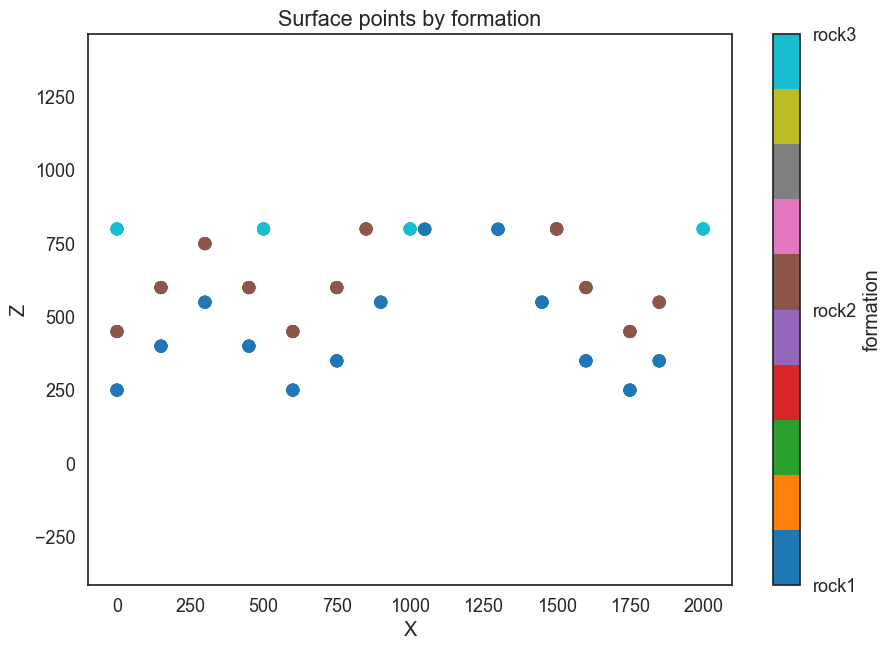

In [5]:
import matplotlib.pyplot as plt

formation_cat = surface_points_df["formation"].astype("category")

plt.scatter(
    surface_points_df["X"],
    surface_points_df["Z"],
    c=formation_cat.cat.codes,   # numeric codes for cmap
    cmap="tab10"
)

cbar = plt.colorbar(ticks=range(len(formation_cat.cat.categories)))
cbar.ax.set_yticklabels(formation_cat.cat.categories)
cbar.set_label("formation")

plt.xlabel("X")
plt.ylabel("Z")
plt.title("Surface points by formation")

plt.axis("equal")
plt.show()

/opt/anaconda3/envs/pgy/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


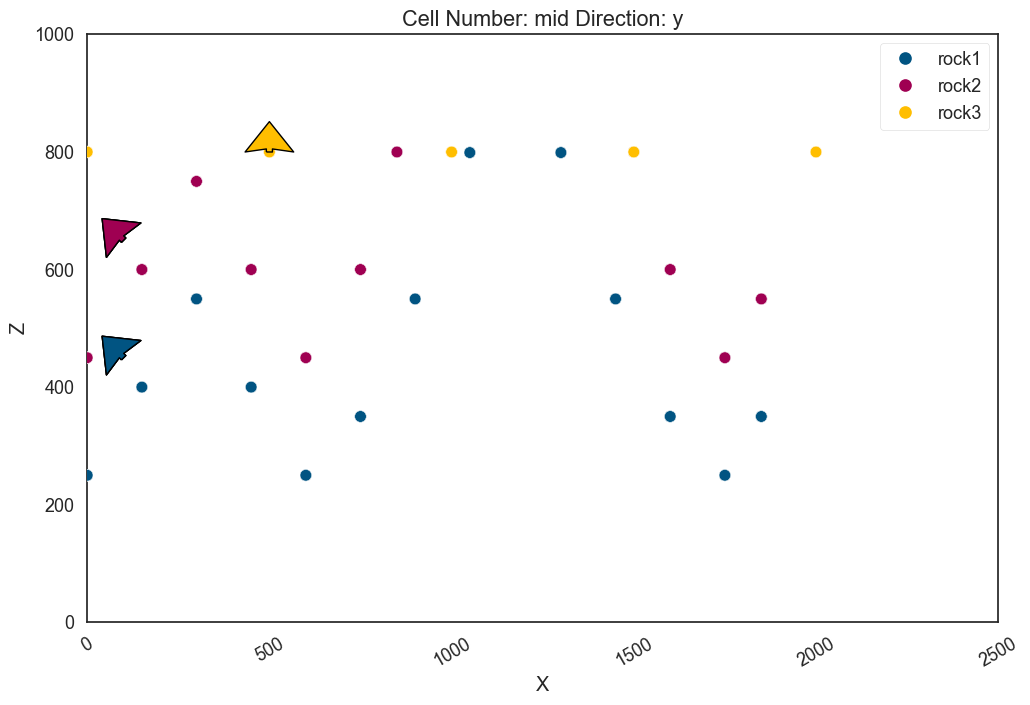

In [6]:
# Display a basic cross section of input data
gpv.plot_2d(geo_model)

In [7]:
import numpy as np

# 2D numpy array of model data (rows: grid cells, columns: x, y, z, [lithology])
coords_2d = geo_model.grid.dense_grid.values

if geo_model.solutions is not None and geo_model.solutions.raw_arrays is not None:
    lith = np.asarray(geo_model.solutions.raw_arrays.lith_block).reshape(-1, 1)
    geo_model_2d = np.hstack([coords_2d, lith])
else:
    geo_model_2d = coords_2d

# Export to disk
np.save("geo_model_2d.npy", geo_model_2d)

geo_model_2d

array([[  12.5,   12.5,   12.5],
       [  12.5,   12.5,   37.5],
       [  12.5,   12.5,   62.5],
       ...,
       [2487.5,  987.5,  937.5],
       [2487.5,  987.5,  962.5],
       [2487.5,  987.5,  987.5]])

In [8]:
# Manually add a surface point
gp.add_surface_points(
    geo_model=geo_model,
    x=[2250],
    y=[500],
    z=[750],
    elements_names=['rock1']
)

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=default_formation,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=rock1,
	color=#015482,
	is_active=True
),
Element(
	name=rock2,
	color=#9f0052,
	is_active=True
),
Element(
	name=rock3,
	color=#ffbe00,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

/opt/anaconda3/envs/pgy/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


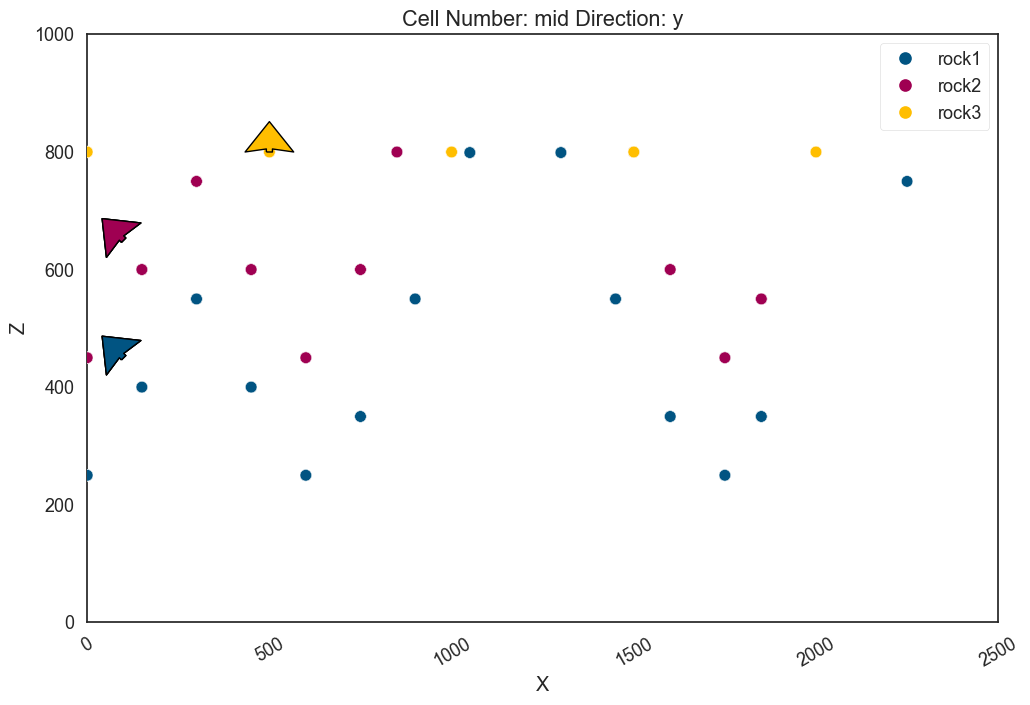

In [9]:
# Show added point in cross section
gpv.plot_2d(geo_model)

In [10]:
# View structural frame
geo_model.structural_frame

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=default_formation,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=rock1,
	color=#015482,
	is_active=True
),
Element(
	name=rock2,
	color=#9f0052,
	is_active=True
),
Element(
	name=rock3,
	color=#ffbe00,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

In [11]:
# View structural elements
geo_model.structural_frame.structural_elements

[Element(
 	name=rock1,
 	color=#015482,
 	is_active=True
 ),
 Element(
 	name=rock2,
 	color=#9f0052,
 	is_active=True
 ),
 Element(
 	name=rock3,
 	color=#ffbe00,
 	is_active=True
 ),
 Element(
 	name=basement,
 	color=#728f02,
 	is_active=True
 )]

In [12]:
# Define structural groups and age/stratigraphic relationship
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "Strat_Series2": ("rock3"),
        "Strat_Series1": ("rock2", "rock1")
    }
)

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Strat_Series2,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=rock3,
	color=#ffbe00,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=rock2,
	color=#9f0052,
	is_active=True
),
Element(
	name=rock1,
	color=#015482,
	is_active=True
)
]
)
],
	fault_relations=
[[False, False],
 [False, False]],

In [13]:
# View interpolation options
geo_model.interpolation_options

InterpolationOptions(kernel_options={'range': 1.7, 'c_o': 10, 'uni_degree': 1, 'i_res': 4, 'gi_res': 2, 'number_dimensions': 3, 'kernel_function': <AvailableKernelFunctions.cubic: KernelFunction(base_function=<function cubic_function at 0x113d42c20>, derivative_div_r=<function cubic_function_p_div_r at 0x113d42e60>, second_derivative=<function cubic_function_a at 0x113d42ef0>, consume_sq_distance=False)>, 'kernel_solver': <Solvers.DEFAULT: 1>, 'compute_condition_number': False, 'optimizing_condition_number': False, 'condition_number': None}, evaluation_options={'_number_octree_levels': 1, '_number_octree_levels_surface': 4, 'octree_curvature_threshold': -1, 'octree_error_threshold': 1.0, 'octree_min_level': 2, 'mesh_extraction': True, 'mesh_extraction_masking_options': <MeshExtractionMaskingOptions.INTERSECT: 3>, 'mesh_extraction_fancy': True, 'evaluation_chunk_size': 500000, 'compute_scalar_gradient': False, 'verbose': False}, temp_interpolation_values=<gempy_engine.core.data.options.temp_interpolation_values.TempInterpolationValues object at 0x31610bbb0>, debug=True, cache_mode=CacheMode.IN_MEMORY_CACHE, cache_model_name=tutorial_model, block_solutions_type=BlockSolutionType.DENSE_GRID, sigmoid_slope=5000000, debug_water_tight=False)

In [14]:
# Compute a solution for the model
gp.compute_model(geo_model)

Setting Backend To: AvailableBackends.numpy
Chunking done: 7 chunks
Chunking done: 30 chunks


Solutions(4 Octree Levels, 3 DualContouringMeshes)

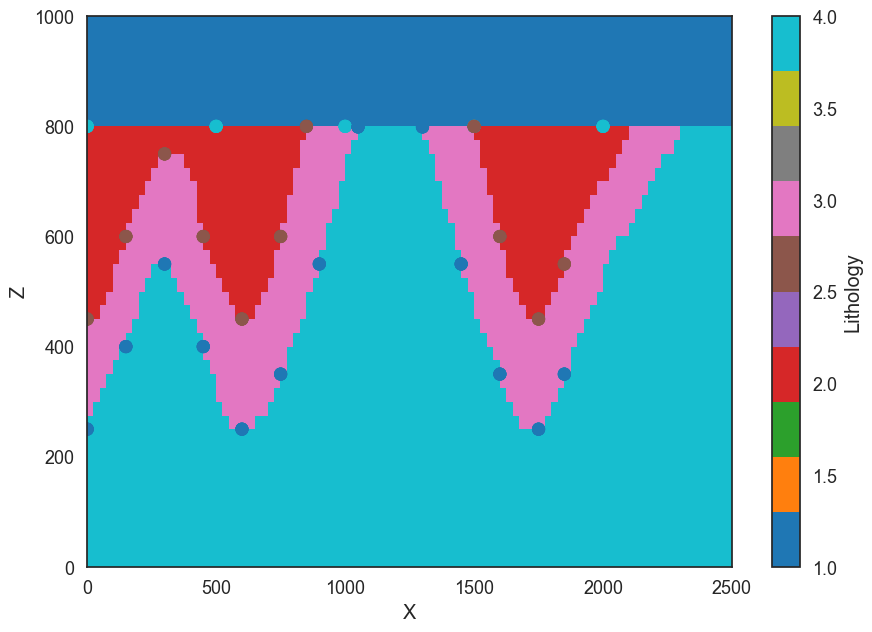

In [15]:
import matplotlib.pyplot as plt

nx, ny, nz = geo_model.grid.dense_grid.resolution  # [100, 40, 40]

# Use lithology from geo_model_2d if present, otherwise fall back to existing lith/model solution
if geo_model_2d.shape[1] > 3:
    lith_flat = geo_model_2d[:, 3]
elif 'lith' in globals():
    lith_flat = lith.ravel()
elif geo_model.solutions is not None and geo_model.solutions.raw_arrays is not None:
    lith_flat = np.asarray(geo_model.solutions.raw_arrays.lith_block).ravel()
else:
    raise ValueError("Lithology data is not available yet. Run gp.compute_model(geo_model) first.")

# X-Z slice at middle Y
y_idx = ny // 2
lith_3d = lith_flat.reshape(nx, ny, nz)
lith_3d_2d=lith_3d[:, y_idx, :].T


extent = geo_model.grid.dense_grid.extent  # [xmin, xmax, ymin, ymax, zmin, zmax]
plt.imshow(
    lith_3d_2d,   # shape -> (nz, nx)
    origin='lower',
    extent=(extent[0], extent[1], extent[4], extent[5]),
    aspect='auto',
    cmap="tab10"
)
plt.xlabel("X")
plt.ylabel("Z")
plt.colorbar(label="Lithology")

plt.scatter(
    surface_points_df["X"],
    surface_points_df["Z"],
    c=formation_cat.cat.codes,   # numeric codes for cmap
    cmap="tab10"
)



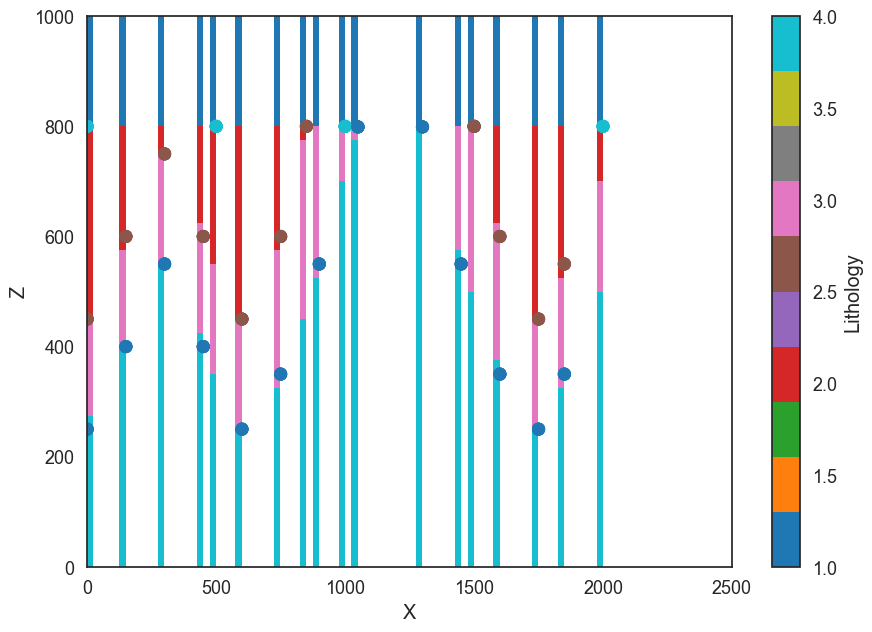

In [16]:
# Use uppercase 'X' (the dataframe column is 'X', not 'x')
x_vals = surface_points_df["X"].to_numpy()

# X coordinates of model grid columns (same x-axis used by lith_3d_2d)
x_grid = np.unique(coords_2d[:, 0])  # length should be nx

# Nearest column index in lith_3d_2d for each surface point X
x_idx = np.abs(x_grid[None, :] - x_vals[:, None]).argmin(axis=1)

# Optional: attach indices to the dataframe
surface_points_with_idx = surface_points_df.copy()
surface_points_with_idx["x_idx_lith_2d"] = x_idx

# Unique lith_3d_2d columns that contain at least one surface point
unique_x_idx = np.unique(x_idx)

surface_points_with_idx[["X", "x_idx_lith_2d"]], unique_x_idx


lith_3d_2d_copy=np.float32(np.copy(lith_3d_2d))
lith_3d_2d_copy[:, ~np.isin(np.arange(lith_3d_2d_copy.shape[1]), unique_x_idx)] = np.nan #


plt.imshow(
    lith_3d_2d_copy,   # shape -> (nz, nx)
    origin='lower',
    extent=(extent[0], extent[1], extent[4], extent[5]),
    aspect='auto',
    cmap="tab10"
)
plt.xlabel("X")
plt.ylabel("Z")
plt.colorbar(label="Lithology")

plt.scatter(
    surface_points_df["X"],
    surface_points_df["Z"],
    c=formation_cat.cat.codes,   # numeric codes for cmap
    cmap="tab10"
)


np.save("lith_3d_2d_with_points.npy", lith_3d_2d_copy)
surface_points_df.to_csv("surface_points_with_indices.csv", index=False)
np.save("lith_3d_2d.npy", lith_3d_2d)
orientations_df.to_csv("orientations_with_indices.csv", index=False)



/opt/anaconda3/envs/pgy/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


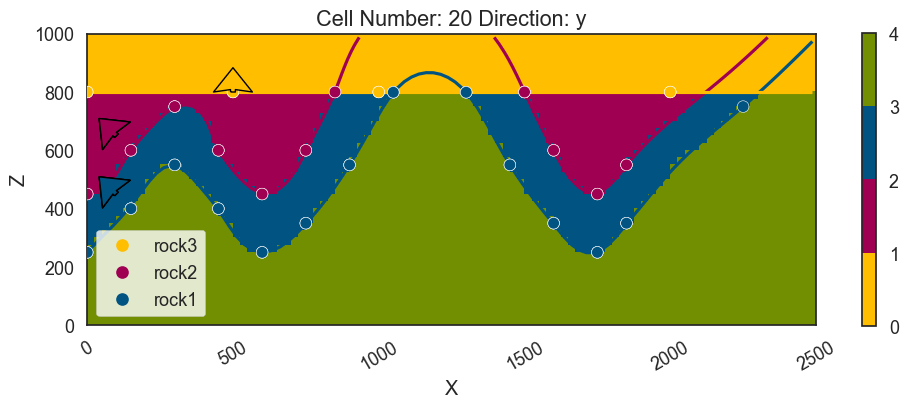

In [21]:
# Display the result in 2d section
gpv.plot_2d(geo_model, cell_number=20)

In [14]:
# Some examples of how to access results
print(geo_model.solutions.raw_arrays.lith_block)
print(geo_model.grid.dense_grid.values)

[4 4 4 ... 1 1 1]
[[  12.5   12.5   12.5]
 [  12.5   12.5   37.5]
 [  12.5   12.5   62.5]
 ...
 [2487.5  987.5  937.5]
 [2487.5  987.5  962.5]
 [2487.5  987.5  987.5]]


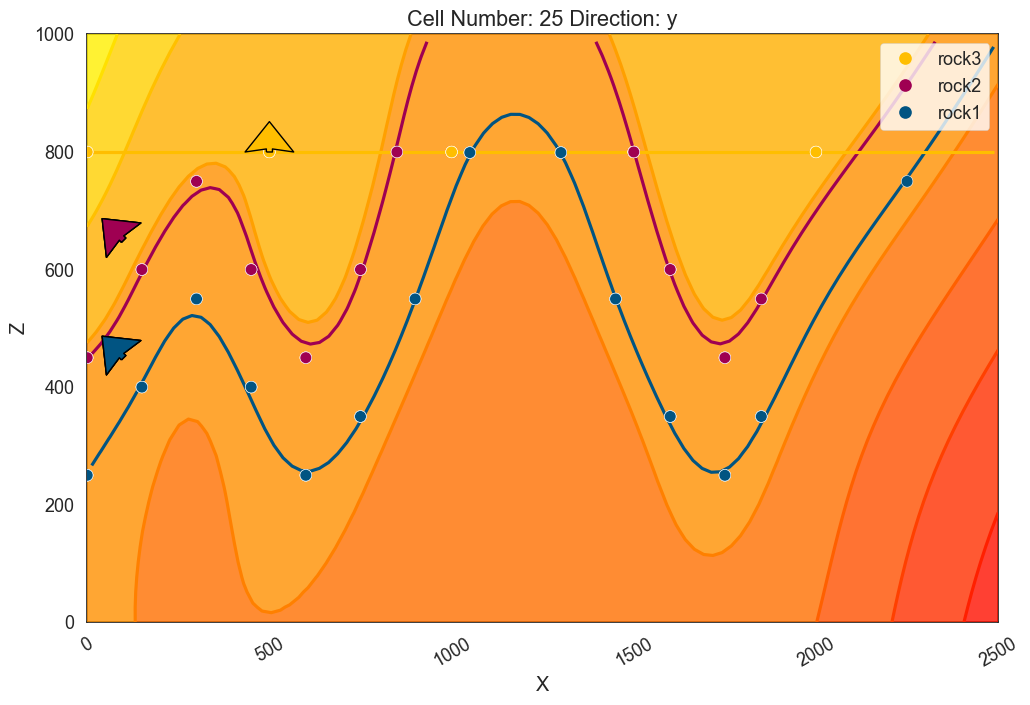

In [15]:
# 2d plotting options
gpv.plot_2d(geo_model, show_value=True, show_lith=False, show_scalar=True, series_n=1, cell_number=25)

In [17]:
# Create custom section lines
gp.set_section_grid(
    grid=geo_model.grid,
    section_dict={
        'section1': ([0, 0], [2500, 1000], [100, 50]),
        'section2': ([1000, 1000], [1500, 0], [100, 100]),
    }
)

Active grids: GridTypes.NONE|SECTIONS|DENSE


,start,stop,resolution,dist
section1,"[0, 0]","[2500, 1000]","[100, 50]",2692.582404
section2,"[1000, 1000]","[1500, 0]","[100, 100]",1118.033989


/opt/anaconda3/envs/pgy/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:202: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.fig.show()


<function gempy_viewer.modules.plot_2d.drawer_traces_2d.plot_section_traces(gempy_model: gempy.core.data.geo_model.GeoModel, ax, section_names: list[str] = None)>

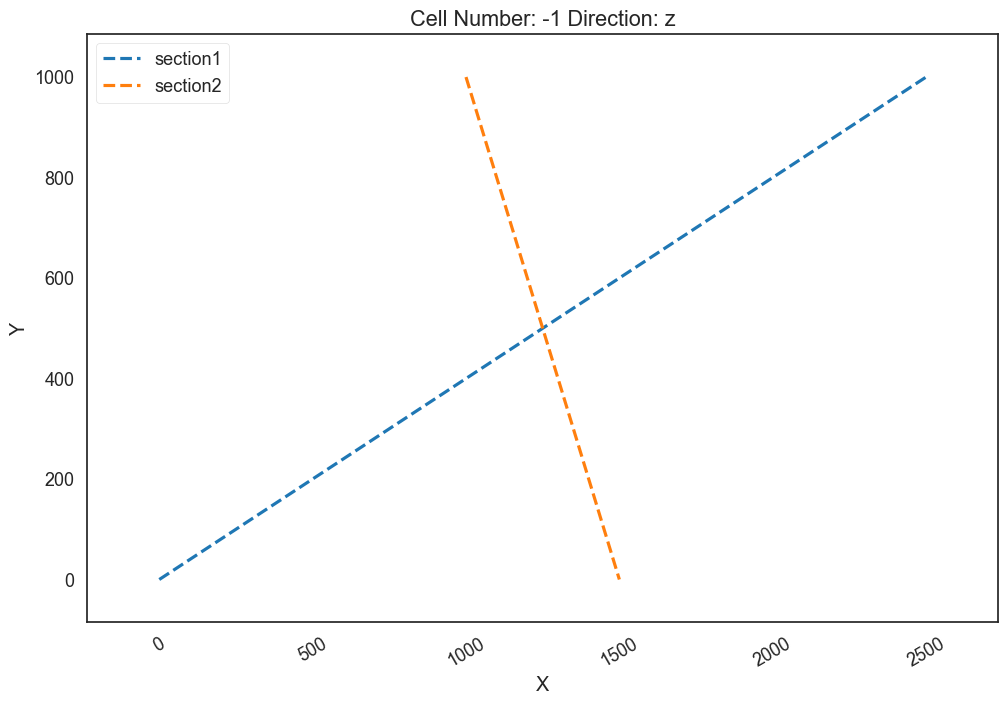

In [18]:
# Show custom cross-section traces
gpv.plot_section_traces(geo_model)

In [19]:
# Recompute model as a new grid was added
gp.compute_model(geo_model)

Setting Backend To: AvailableBackends.numpy
Chunking done: 8 chunks
Chunking done: 33 chunks


Solutions(4 Octree Levels, 3 DualContouringMeshes)

/opt/anaconda3/envs/pgy/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_sections_api.py:112: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
/opt/anaconda3/envs/pgy/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


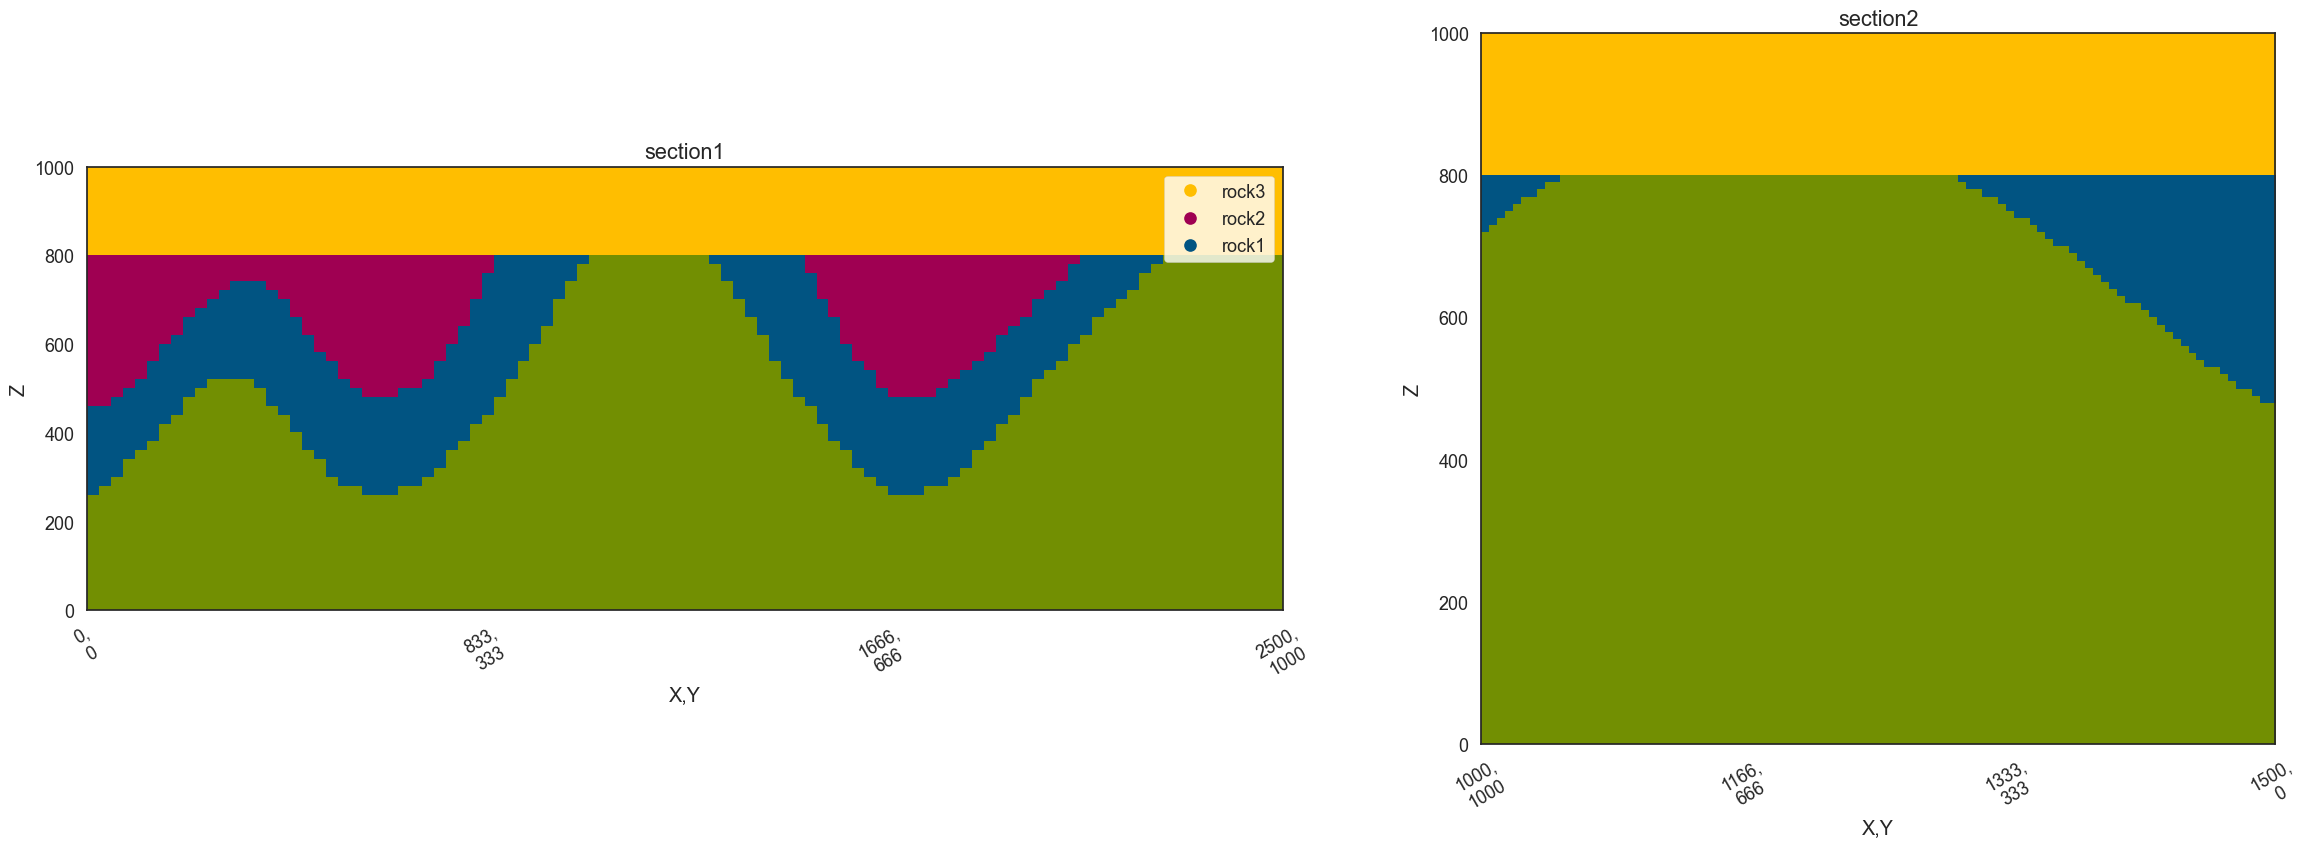

In [20]:
# Display custom cross-sections
gpv.plot_2d(geo_model, section_names=['section1', 'section2'], show_data=False)